# Logistic Regression on Brainvita (From Scratch)

This notebook uses the custom `rice_ml.supervised_learning.LogisticRegression` implementation to classify Brainvita board states as **high mobility** or **low mobility**. A state is labeled high mobility when `num_legal_moves >= 3`, which turns the regression target from the linear notebook into a binary decision problem.

The purpose is to show logistic regression as an interpretable probabilistic baseline: we derive the sigmoid model, fit it with gradient descent, inspect optimization behavior, evaluate classification quality beyond accuracy, and interpret coefficients as changes in log-odds.


## Learning Objectives

1. Explain logistic regression through log-odds, the sigmoid function, and binary cross-entropy.
2. Build a leakage-safe train/test split with train-only standardization.
3. Fit the custom `rice_ml` logistic regression model and tune basic gradient-descent settings.
4. Evaluate a binary classifier with accuracy, precision, recall, F1, confusion matrices, and ROC-AUC.
5. Use thresholds and coefficients to interpret the model as a practical Brainvita mobility classifier.


## Dataset and Classification Target

Each row in the Brainvita dataset is a board-state summary. The features describe peg density, jump opportunities, cluster structure, local adjacency, board position, and reachability. For logistic regression, we convert the legal-move count into a decision target:

$$
y = \mathbb{1}[\text{num\_legal\_moves} \ge 3]
$$

This label asks whether a board state still has several available moves. It is not a win/loss label; it is a mobility label. That distinction matters because a high-mobility state is not necessarily optimal, but it usually gives the player or solver more choices. The positive class is smaller than the negative class, so we report precision, recall, F1, and ROC-AUC instead of relying on accuracy alone.


## 1. Mathematical Foundation

Logistic regression models the **log-odds** of the positive class as a linear function of the features:

$$
\log\frac{p(x)}{1-p(x)} = w^T x + b
$$

The sigmoid function maps that linear score into a probability:

$$
p(x)=\sigma(w^Tx+b)=\frac{1}{1+e^{-(w^Tx+b)}}
$$

The model is trained by minimizing binary cross-entropy:

$$
\mathcal{L} = -\frac{1}{n}\sum_i\left[y_i\log p_i + (1-y_i)\log(1-p_i)\right]
$$

Because the custom implementation uses gradient descent, feature scaling matters. Large feature-scale differences can make the loss surface harder to optimize, so we standardize using training-set means and standard deviations only.


## 2. Why Logistic Instead of Perceptron

- probabilistic output instead of hard labels only
- smooth differentiable objective
- threshold can be tuned to precision/recall tradeoff


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start='.'):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / 'src' / 'rice_ml').exists() and (q / 'data' / 'brainvita_dataset.csv').exists():
            return q
    raise FileNotFoundError('Could not locate repository root with src/rice_ml and data/brainvita_dataset.csv')

ROOT = find_repo_root('.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_PATH = ROOT / 'data' / 'brainvita_dataset.csv'

preferred_features = ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']

from rice_ml.supervised_learning import LogisticRegression

In [2]:
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')

exclude_cols = {
    'num_legal_moves',
    'board_state',
    'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2',
    'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2',
}

raw_feature_cols = [c for c in header if c not in exclude_cols]
selected_cols = raw_feature_cols + ['num_legal_moves']
selected_idx = [header.index(c) for c in selected_cols]
arr = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1, usecols=selected_idx, dtype=float)

X_raw = arr[:, :-1]
y_reg = arr[:, -1]
y_bin = (y_reg >= 3.0).astype(int)

feature_cols = [c for c in preferred_features if c in raw_feature_cols]
keep_idx = [raw_feature_cols.index(c) for c in feature_cols]
X = X_raw[:, keep_idx]

print('Rows:', f'{X.shape[0]:,}')
print('Features:', X.shape[1])
print('Positive class rate (num_legal_moves >= 3):', round(float(y_bin.mean()), 4))
print('Feature set:', feature_cols)


Rows: 238,486
Features: 15
Positive class rate (num_legal_moves >= 3): 0.2918
Feature set: ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']


In [3]:
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)
split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y_bin[train_idx], y_bin[test_idx]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma_safe = np.where(sigma < 1e-12, 1.0, sigma)

X_train = (X_train_raw - mu) / sigma_safe
X_test = (X_test_raw - mu) / sigma_safe

print('Train samples:', f'{X_train.shape[0]:,}', '| Test samples:', f'{X_test.shape[0]:,}')


Train samples: 190,788 | Test samples: 47,698


## 3. Majority-Class Baseline

The positive class is not evenly balanced, so the first question is whether logistic regression beats the trivial strategy of always predicting the more common class. This baseline can have deceptively decent accuracy, but it has zero recall for the minority class if it always predicts low mobility.


In [4]:
def class_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': np.array([[tn, fp], [fn, tp]])}

majority_class = int(np.bincount(y_train).argmax())
majority_pred = np.full_like(y_test, majority_class)
majority_met = class_metrics(y_test, majority_pred)

print('Majority class:', majority_class)
print('Majority baseline (test):', {k: round(v, 4) for k, v in majority_met.items() if k != 'cm'})
print('Confusion matrix [ [TN, FP], [FN, TP] ]')
print(majority_met['cm'])


Majority class: 0
Majority baseline (test): {'acc': 0.7089, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
Confusion matrix [ [TN, FP], [FN, TP] ]
[[33813     0]
 [13885     0]]


## 4. Learning-Rate and Iteration Sweep

We fit several gradient-descent configurations and select the one with the best test F1 score. F1 is a better selection criterion than raw accuracy here because the positive class is less common and recall matters for identifying high-mobility states.

In [5]:
def class_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': np.array([[tn, fp], [fn, tp]])}

configs = [
    {'learning_rate': 0.03, 'max_iter': 600},
    {'learning_rate': 0.05, 'max_iter': 900},
    {'learning_rate': 0.10, 'max_iter': 1200},
]

trials = []
for cfg in configs:
    m = LogisticRegression(learning_rate=cfg['learning_rate'], max_iter=cfg['max_iter'], tol=1e-7, fit_intercept=True)
    m.fit(X_train, y_train)
    met = class_metrics(y_test, m.predict(X_test))
    trials.append((cfg, met, m))

print('Sweep results (test)')
print('-' * 84)
print(f"{'lr':>8} {'max_iter':>10} {'acc':>10} {'precision':>10} {'recall':>10} {'f1':>10}")
print('-' * 84)
for cfg, met, _ in trials:
    print(f"{cfg['learning_rate']:>8.3f} {cfg['max_iter']:>10d} {met['acc']:>10.4f} {met['precision']:>10.4f} {met['recall']:>10.4f} {met['f1']:>10.4f}")
print('-' * 84)

best_cfg, best_met, best_model = sorted(trials, key=lambda t: t[1]['f1'], reverse=True)[0]
print('Selected config:', best_cfg)


Sweep results (test)
------------------------------------------------------------------------------------
      lr   max_iter        acc  precision     recall         f1
------------------------------------------------------------------------------------
   0.030        600     0.9782     0.9677     0.9571     0.9624
   0.050        900     0.9821     0.9802     0.9578     0.9689
   0.100       1200     0.9861     0.9856     0.9664     0.9759
------------------------------------------------------------------------------------
Selected config: {'learning_rate': 0.1, 'max_iter': 1200}


## 5. Final Model Metrics

The confusion matrices show where the classifier makes mistakes. For this task, false negatives are high-mobility states predicted as low mobility, while false positives are constrained states predicted as high mobility.

Train metrics: {'acc': 0.9863, 'precision': 0.9848, 'recall': 0.9681, 'f1': 0.9764}
Test metrics : {'acc': 0.9861, 'precision': 0.9856, 'recall': 0.9664, 'f1': 0.9759}


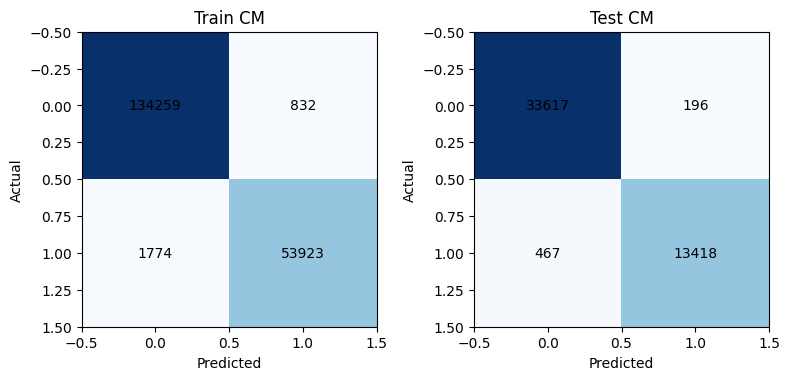

In [6]:
def class_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': np.array([[tn, fp], [fn, tp]])}

model = best_model
train_met = class_metrics(y_train, model.predict(X_train))
test_met = class_metrics(y_test, model.predict(X_test))

print('Train metrics:', {k: round(v, 4) for k, v in train_met.items() if k != 'cm'})
print('Test metrics :', {k: round(v, 4) for k, v in test_met.items() if k != 'cm'})

fig, ax = plt.subplots(1, 2, figsize=(8, 3.8))
for i, (cm, title) in enumerate([(train_met['cm'], 'Train CM'), (test_met['cm'], 'Test CM')]):
    ax[i].imshow(cm, cmap='Blues')
    ax[i].set_title(title)
    ax[i].set_xlabel('Predicted')
    ax[i].set_ylabel('Actual')
    for r in range(2):
        for c in range(2):
            ax[i].text(c, r, int(cm[r, c]), ha='center', va='center')
plt.tight_layout()
plt.show()


## 6. Optimization Diagnostics

The loss curve checks whether gradient descent actually optimized the binary cross-entropy objective. A smooth downward curve is evidence that the learning rate is reasonable for the standardized feature scale.

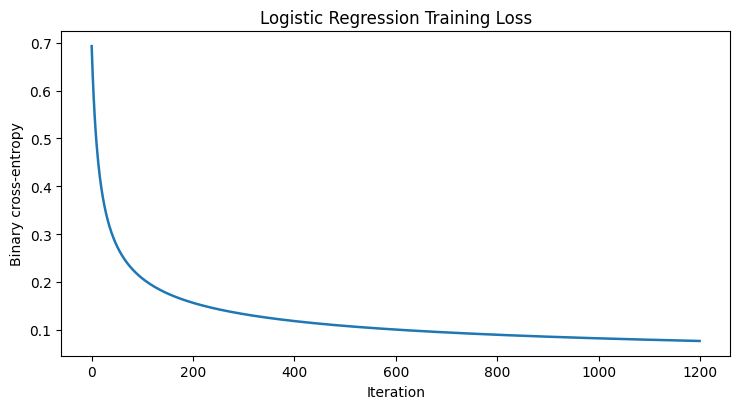

Iterations: 1200
Initial loss: 0.693147
Final loss  : 0.076644


In [7]:
plt.figure(figsize=(7.5, 4.2))
plt.plot(model.loss_history_, linewidth=1.8)
plt.title('Logistic Regression Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Binary cross-entropy')
plt.tight_layout()
plt.show()

print('Iterations:', len(model.loss_history_))
print('Initial loss:', round(float(model.loss_history_[0]), 6))
print('Final loss  :', round(float(model.loss_history_[-1]), 6))


## 7. ROC and Threshold Analysis

The default threshold of `0.5` is not the only possible decision rule. ROC-AUC evaluates ranking quality across all thresholds, and the threshold table shows how precision and recall move in opposite directions as we become more or less strict about calling a state high mobility.

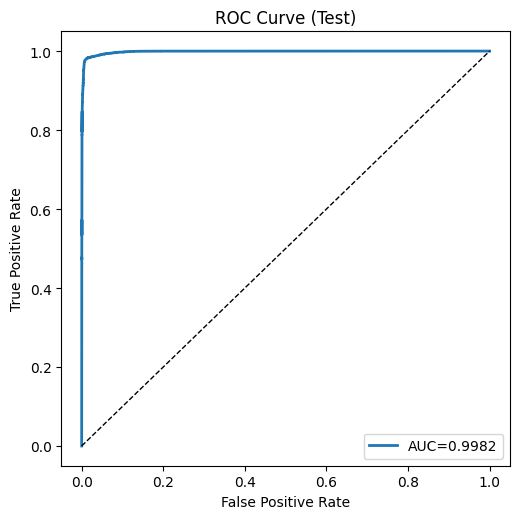

In [8]:
fpr, tpr, auc = model.roc_curve(X_test, y_test)
plt.figure(figsize=(5.3, 5.3))
plt.plot(fpr, tpr, label=f'AUC={auc:.4f}', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test)')
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
def class_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': np.array([[tn, fp], [fn, tp]])}

probs = model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.20, 0.80, 13)

print('Threshold sensitivity (test)')
print('-' * 92)
print(f"{'thr':>8} {'acc':>10} {'precision':>12} {'recall':>12} {'f1':>12}")
print('-' * 92)
for th in thresholds:
    pred = (probs >= th).astype(int)
    met = class_metrics(y_test, pred)
    print(f"{th:>8.2f} {met['acc']:>10.4f} {met['precision']:>12.4f} {met['recall']:>12.4f} {met['f1']:>12.4f}")
print('-' * 92)


Threshold sensitivity (test)
--------------------------------------------------------------------------------------------
     thr        acc    precision       recall           f1
--------------------------------------------------------------------------------------------
    0.20     0.9602       0.8850       0.9921       0.9355
    0.25     0.9712       0.9190       0.9882       0.9523
    0.30     0.9777       0.9404       0.9857       0.9625
    0.35     0.9829       0.9590       0.9834       0.9711
    0.40     0.9862       0.9727       0.9801       0.9764
    0.45     0.9873       0.9811       0.9752       0.9781
    0.50     0.9861       0.9856       0.9664       0.9759
    0.55     0.9823       0.9879       0.9508       0.9690
    0.60     0.9766       0.9892       0.9298       0.9586
    0.65     0.9706       0.9913       0.9070       0.9473
    0.70     0.9639       0.9947       0.8805       0.9341
    0.75     0.9557       0.9961       0.8511       0.9179
    0.80     0.948

## 8. Coefficient / Odds-Ratio Interpretation

The coefficients are attached to standardized features, so a one-unit change means a one-standard-deviation increase in that feature. Positive coefficients increase the log-odds of the high-mobility class; `exp(coef)` converts that change into an odds ratio.

In [10]:
coef = model.coef_
order = np.argsort(np.abs(coef))[::-1]

print('Top 12 coefficients (standardized features)')
print('-' * 86)
print(f"{'Rank':<6}{'Feature':<28}{'Coef':>14}{'Odds Ratio exp(coef)':>24}")
print('-' * 86)
for rank, i in enumerate(order[:12], start=1):
    odds = float(np.exp(np.clip(coef[i], -20, 20)))
    print(f"{rank:<6}{feature_cols[i]:<28}{coef[i]:>14.6f}{odds:>24.6f}")
print('-' * 86)


Top 12 coefficients (standardized features)
--------------------------------------------------------------------------------------
Rank  Feature                               Coef    Odds Ratio exp(coef)
--------------------------------------------------------------------------------------
1     jumpable_pegs                     3.490951               32.817147
2     mobility_ratio                    2.355466               10.543042
3     avg_adjacent_pegs                 0.883889                2.420293
4     max_adjacent_empty                0.590454                1.804807
5     max_pegs_reachable                0.529699                1.698420
6     avg_adjacent_empty                0.415532                1.515177
7     peg_ratio                         0.412702                1.510894
8     num_clusters                      0.282427                1.326346
9     board_rows                        0.252537                1.287287
10    board_cols                        0.246063    

## 9. Conclusion

Logistic regression is a strong probabilistic baseline for Brainvita mobility classification. It beats the majority-class reference point, gives useful threshold control, and produces interpretable coefficients that highlight direct mobility features such as `jumpable_pegs` and `mobility_ratio`.

The model is still linear in the log-odds, so it cannot fully represent feature interactions such as how cluster structure and peg density jointly affect move availability. That limitation motivates the ensemble notebook, where tree-based models can capture nonlinear splits without requiring the same standardized linear feature assumptions.
